# ML vs empirical cIM trends
The aim of this notebook is to identify if there are any trends in the differences in performance for the ML vs empirical cIM method; for example does one perform better than the other as the site of interest is better constrained (i.e. more observations)


In [27]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import sim_ranking as sr
import ml_tools as mlt


In [31]:
emp_cim_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/20240301_comparison/synthethic/emp_cIM_perturbed_100r") 
# ml_data_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/archive/0507_1434_lb_15_100_SCweighted_probL2_0p5")

ml_data_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0616_1423_lb_20_100_SCweighted_probL2_0p5")

db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")

In [32]:
def load_cim_data(data_dir: Path, event: str):
	result_ffp = data_dir / event / "empirical_cMVN/cMVN_distributions.pickle"
	return sr.conditional.ConditionalMVNDistribution.load(result_ffp)

In [33]:
meta = mlt.utils.load_yaml(ml_data_dir / "meta.yaml")
run_config = sr.ml.sc_prob.RunParamsConfig.from_dict(meta["run_config"])

sc_sum_df = pd.read_parquet(ml_data_dir / "val_scenario_summary.parquet")
sc_df = pd.read_parquet(ml_data_dir / "val_scenario_results.parquet")

db = sr.db.DB(db_ffp)

In [34]:
meta = mlt.utils.load_yaml(ml_data_dir / "meta.yaml")
run_config = sr.ml.sc_prob.RunParamsConfig.from_dict(meta["run_config"])

ims = np.asarray(run_config.ims)
im_wavg_cols = mlt.array_utils.numpy_str_join("_", run_config.ims, "wavg")
im_wstd_cols = mlt.array_utils.numpy_str_join("_", run_config.ims, "wstd")

In [35]:
## Compute residuals
ml_obs_residuals = sr.ml.sc_prob.compute_ml_residuals_wrt_obs(sc_sum_df, db_ffp, run_config.ims)

emp_cIM_obs_residuals = sr.ml.sc_prob.compute_cIM_residuals_wrt_obs(emp_cim_dir, db_ffp, sr.constants.RankingMethod.emp_cMVN, run_config.ims)

Skipping event 2016p858913 as no cIM data found
Skipping event 2016p886502 as no cIM data found


In [36]:
print(ml_obs_residuals.shape)
ml_obs_residuals = ml_obs_residuals.loc[np.isin(ml_obs_residuals.event_id, emp_cIM_obs_residuals.event_id)]
sc_sum_df = sc_sum_df.loc[np.isin(sc_sum_df.event_id, emp_cIM_obs_residuals.event_id)]
print(ml_obs_residuals.shape)

(606, 33)
(605, 33)


In [37]:
# Only interested in scenarios where both ML and empirical cIM have been computed
emp_cIM_obs_residuals = emp_cIM_obs_residuals.loc[ml_obs_residuals.index]
assert np.all(sc_sum_df.index == ml_obs_residuals.index)
assert np.all(emp_cIM_obs_residuals.index == ml_obs_residuals.index)

In [38]:
cur_im = "pSA_1.0"

## ML residuals vs empirical cIM residuals

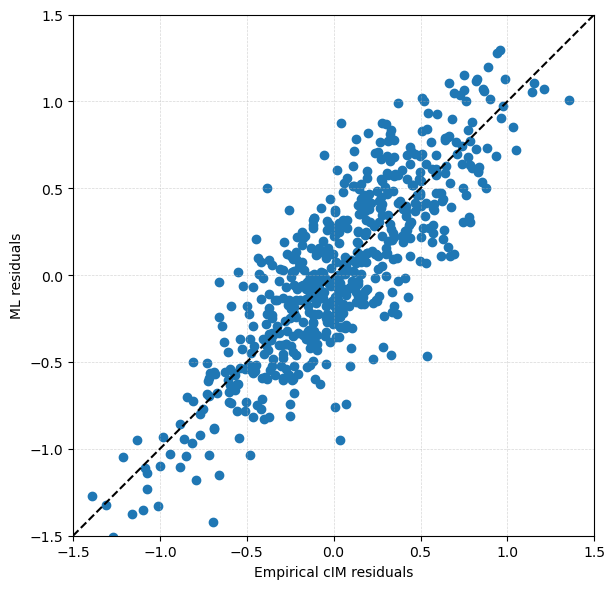

In [45]:

c_key = "n_obs_sites"
# c_key = "min_s2s_dist"

fig, ax = plt.subplots(figsize=(12, 6))

cm = ax.scatter(emp_cIM_obs_residuals[cur_im], ml_obs_residuals[cur_im], alpha=1.0)#, c=sc_sum_df[c_key], cmap="viridis")

ax.set_xlabel("Empirical cIM residuals")
ax.set_ylabel("ML residuals")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

# Add one to one line
ax.plot([-1.5, 1.5], [-1.5, 1.5], c="k", linestyle="--")

# fig.colorbar(cm, pad=0, label=c_key)

ax.set_aspect('equal')

fig.tight_layout()


## Number of observation sites vs Closes observation site distance

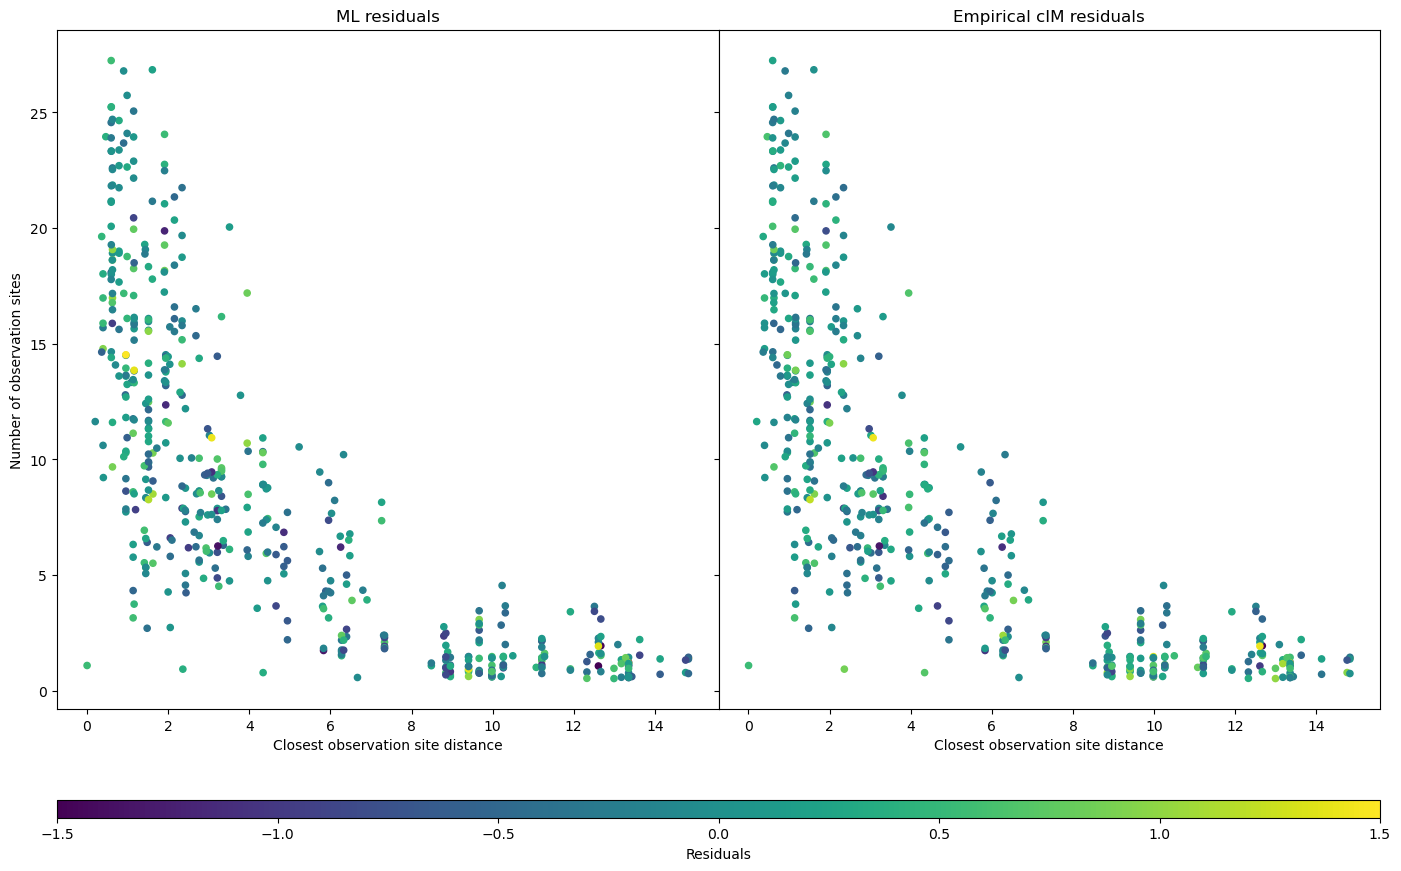

In [57]:
cmap = "viridis"
vmin, vmax = -1.5, 1.5
ms = 20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10), sharex=True, sharey=True)

y_scatter = np.random.uniform(-0.5, 0.5, len(sc_sum_df))

cm = ax1.scatter(sc_sum_df["min_s2s_dist"], sc_sum_df["n_obs_sites"] + y_scatter, c=ml_obs_residuals[cur_im], cmap=cmap, s=ms, vmin=vmin, vmax=vmax)
ax1.set_xlabel("Closest observation site distance")
ax1.set_ylabel("Number of observation sites")
ax1.set_title("ML residuals")

ax2.scatter(sc_sum_df["min_s2s_dist"], sc_sum_df["n_obs_sites"] + y_scatter, c=emp_cIM_obs_residuals[cur_im], cmap=cmap, s=ms, vmin=vmin, vmax=vmax)
ax2.set_title("Empirical cIM residuals")
ax2.set_xlabel("Closest observation site distance")
# ax2.set_ylabel("Number of observation sites")


fig.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)

cbar = fig.colorbar(cm, orientation='horizontal', ax=[ax1, ax2], pad=0.1, aspect=75)
cbar.set_label('Residuals')


## Minimum site-to-site distance vs residuals

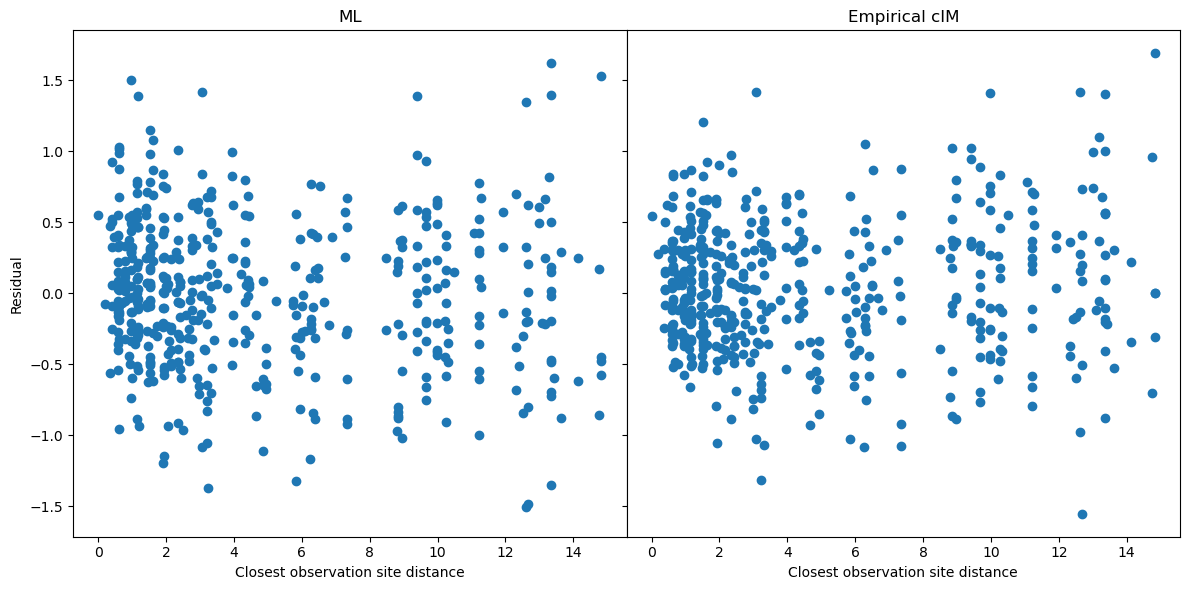

In [61]:
# cmap = "viridis"
# vmin, vmax = -1.5, 1.5
ms = 20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

y_scatter = np.random.uniform(-0.5, 0.5, len(sc_sum_df))

ax1.scatter(sc_sum_df["min_s2s_dist"], ml_obs_residuals[cur_im])
ax1.set_xlabel("Closest observation site distance")
ax1.set_ylabel("Residual")
ax1.set_title("ML")

ax2.scatter(sc_sum_df["min_s2s_dist"], emp_cIM_obs_residuals[cur_im])
ax2.set_xlabel("Closest observation site distance")
ax2.set_title("Empirical cIM")

fig.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)

# cbar = fig.colorbar(cm, orientation='horizontal', ax=[ax1, ax2], pad=0.1, aspect=75)
# cbar.set_label('Residuals')


## Grouping
- Split into x groups
- Create histograms for IMs per group
- Create mean & std plot (wrt period) with line per group


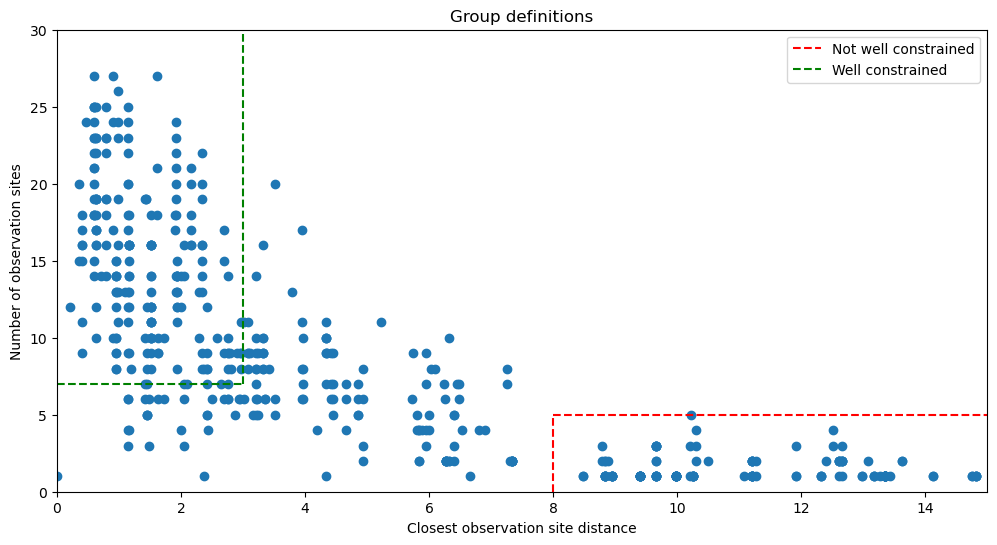

In [70]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(sc_sum_df["min_s2s_dist"], sc_sum_df["n_obs_sites"])
ax.set_xlabel("Closest observation site distance")
ax.set_ylabel("Number of observation sites")
ax.set_xlim(0, 15)
ax.set_ylim(0, 30)

ax.plot([8, 15], [5, 5], c="r", label="Not well constrained", linestyle="--")
ax.plot([8, 8], [0, 5], c="r", linestyle="--")

ax.plot([3, 3], [7, 30], c="g", label="Well constrained", linestyle="--")
ax.plot([0, 3], [7, 7], c="g", linestyle="--")

ax.set_title("Group definitions")

ax.legend();


In [25]:
nwc = (sc_sum_df["min_s2s_dist"] >= 8) & (sc_sum_df["n_obs_sites"] <= 5)
wc = (sc_sum_df["min_s2s_dist"] <= 3) & (sc_sum_df["n_obs_sites"] >= 7)
rwc = ~nwc & ~wc

print(f"Not well constrained: {np.count_nonzero(nwc)}")
print(f"Reasonably well constrained: {np.count_nonzero(rwc)}")
print(f"Well constrained: {np.count_nonzero(wc)}")

Not well constrained: 110
Reasonably well constrained: 239
Well constrained: 256


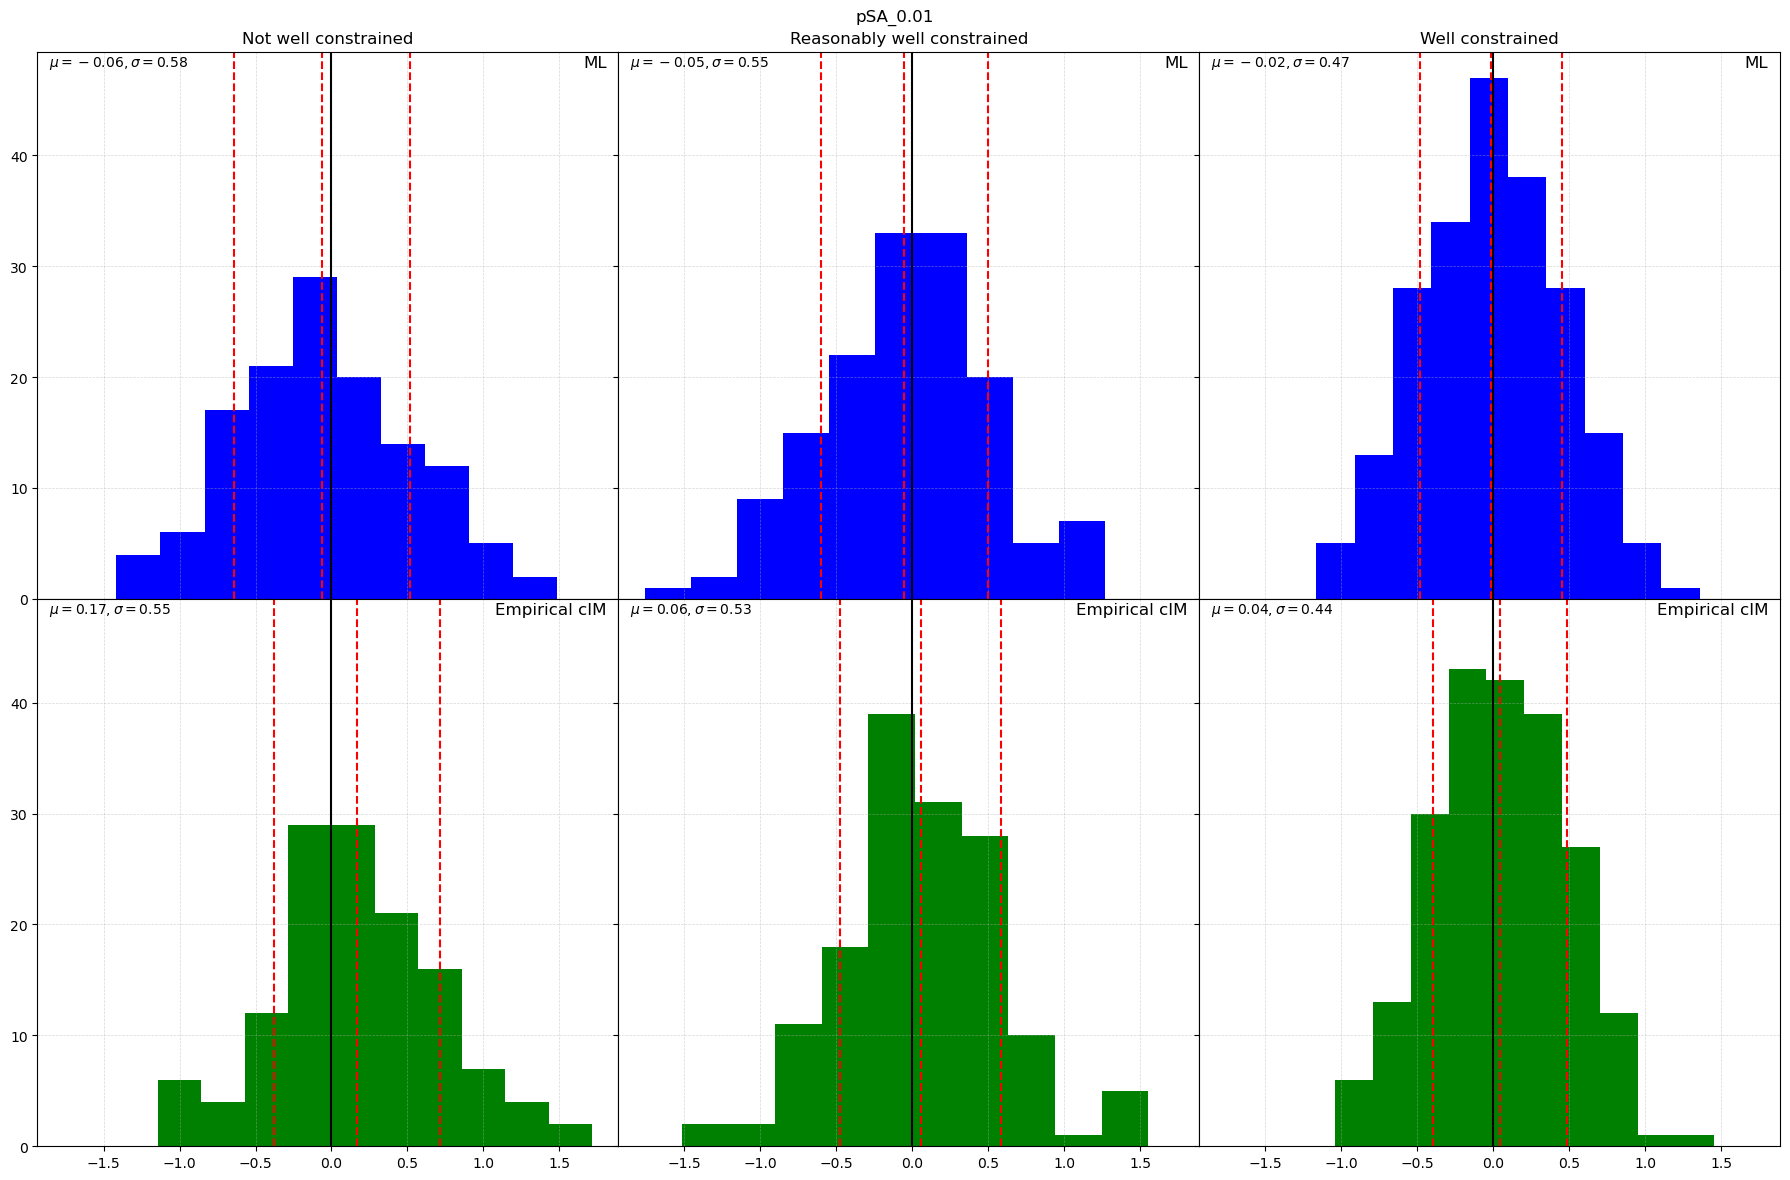

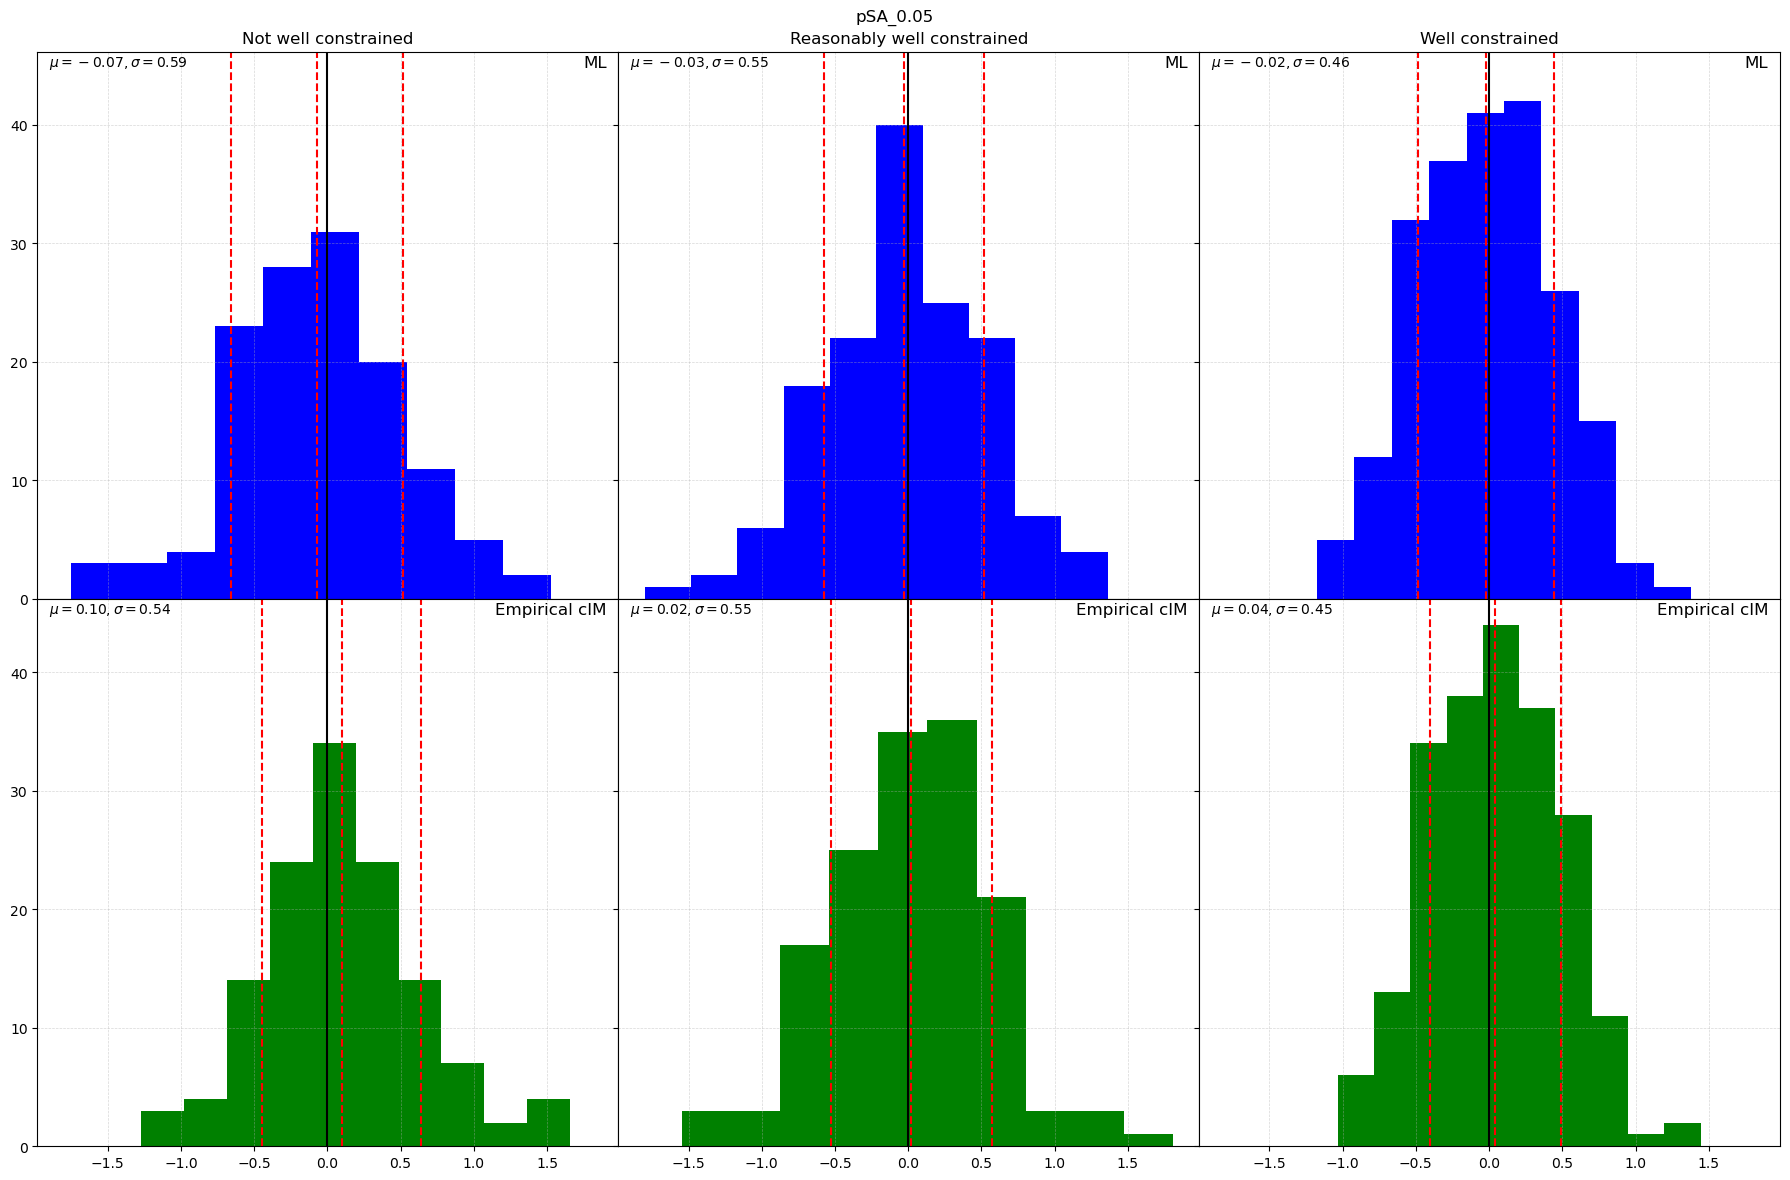

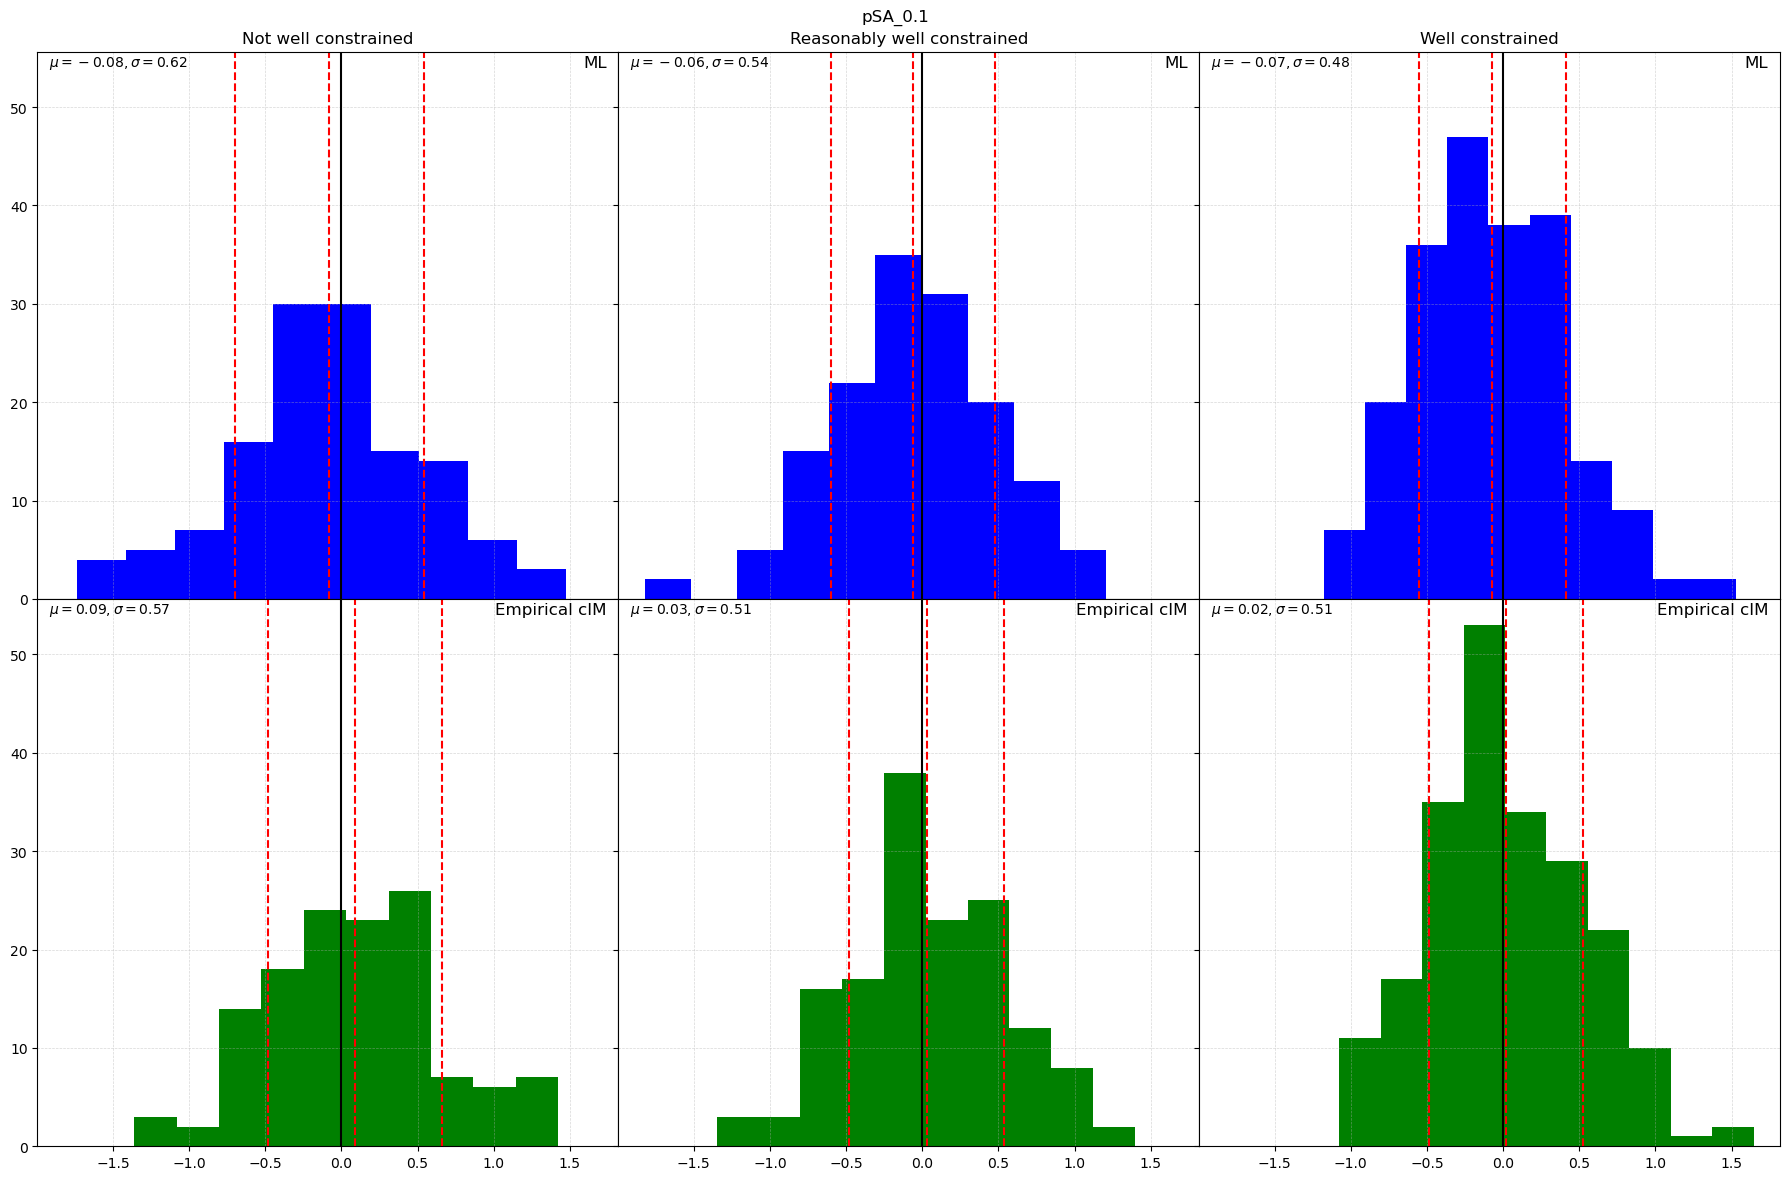

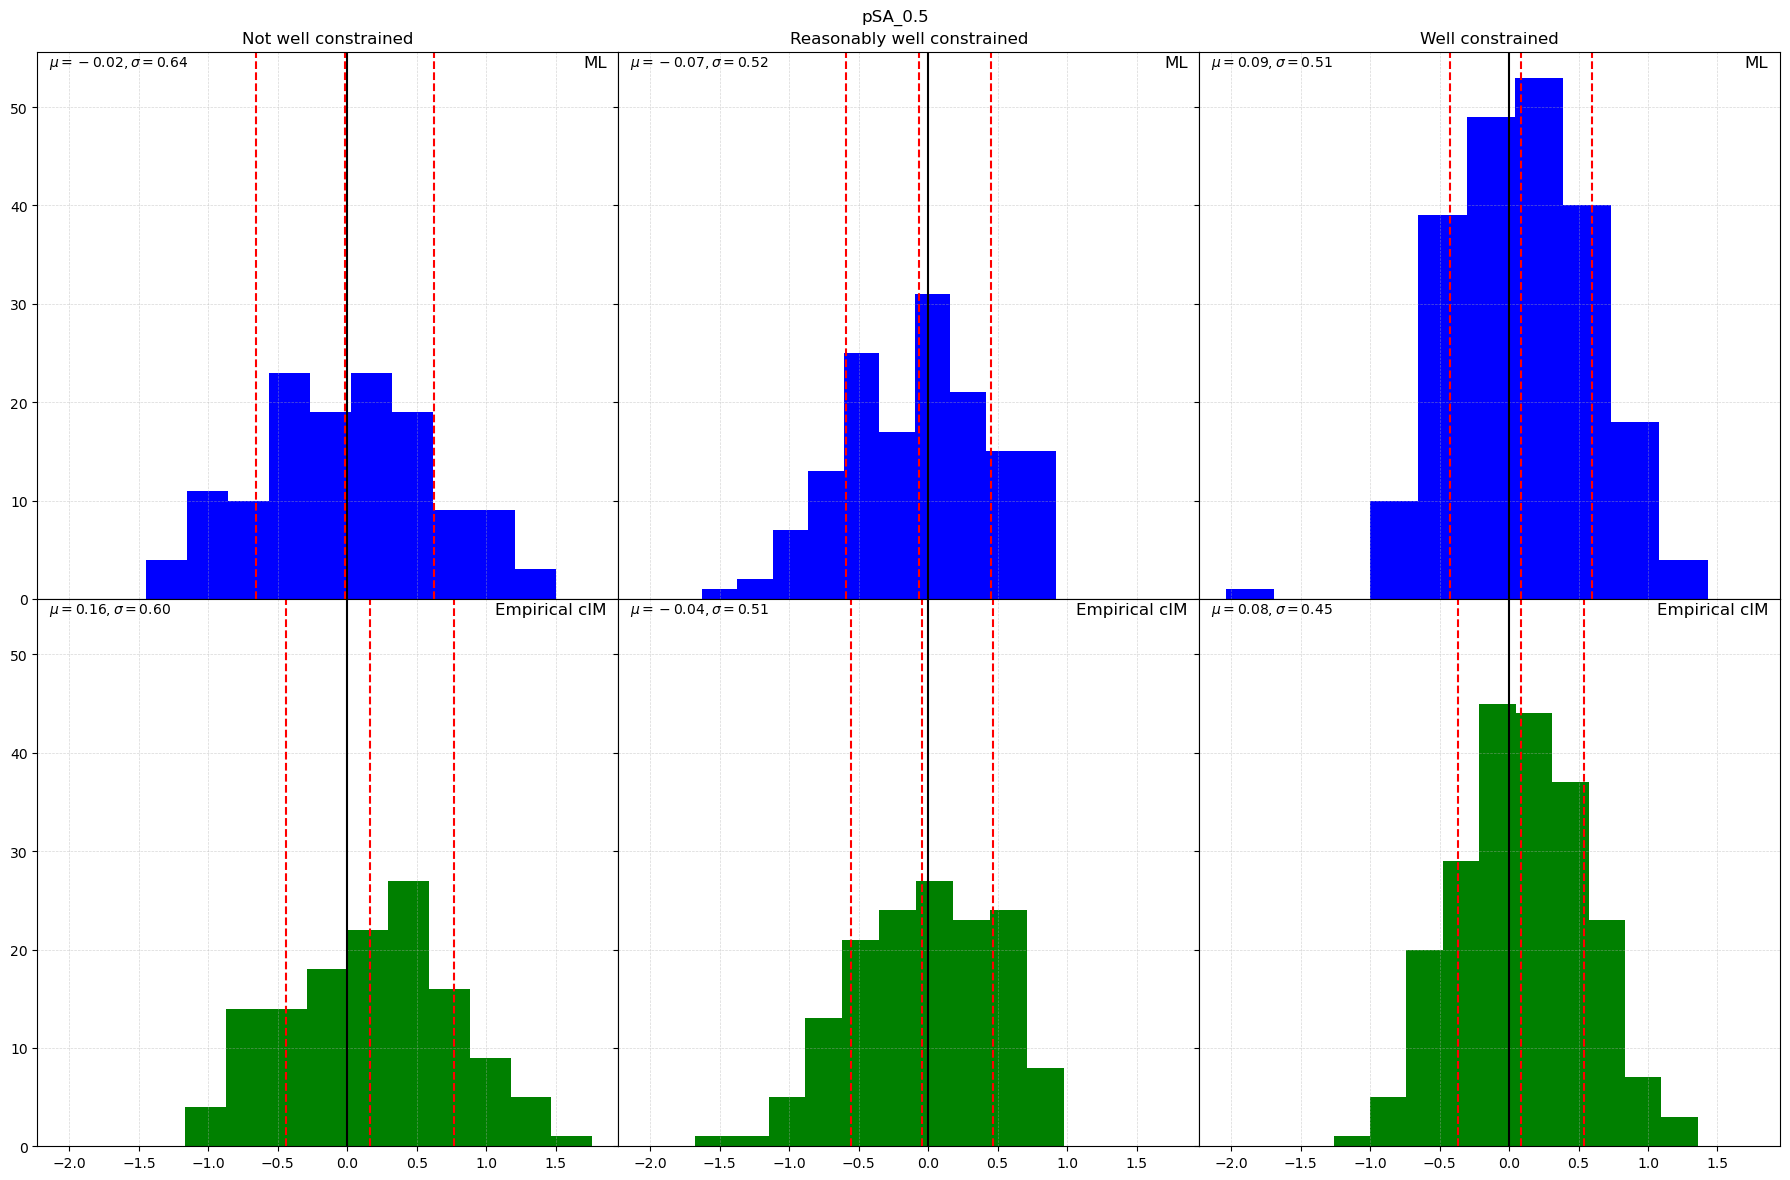

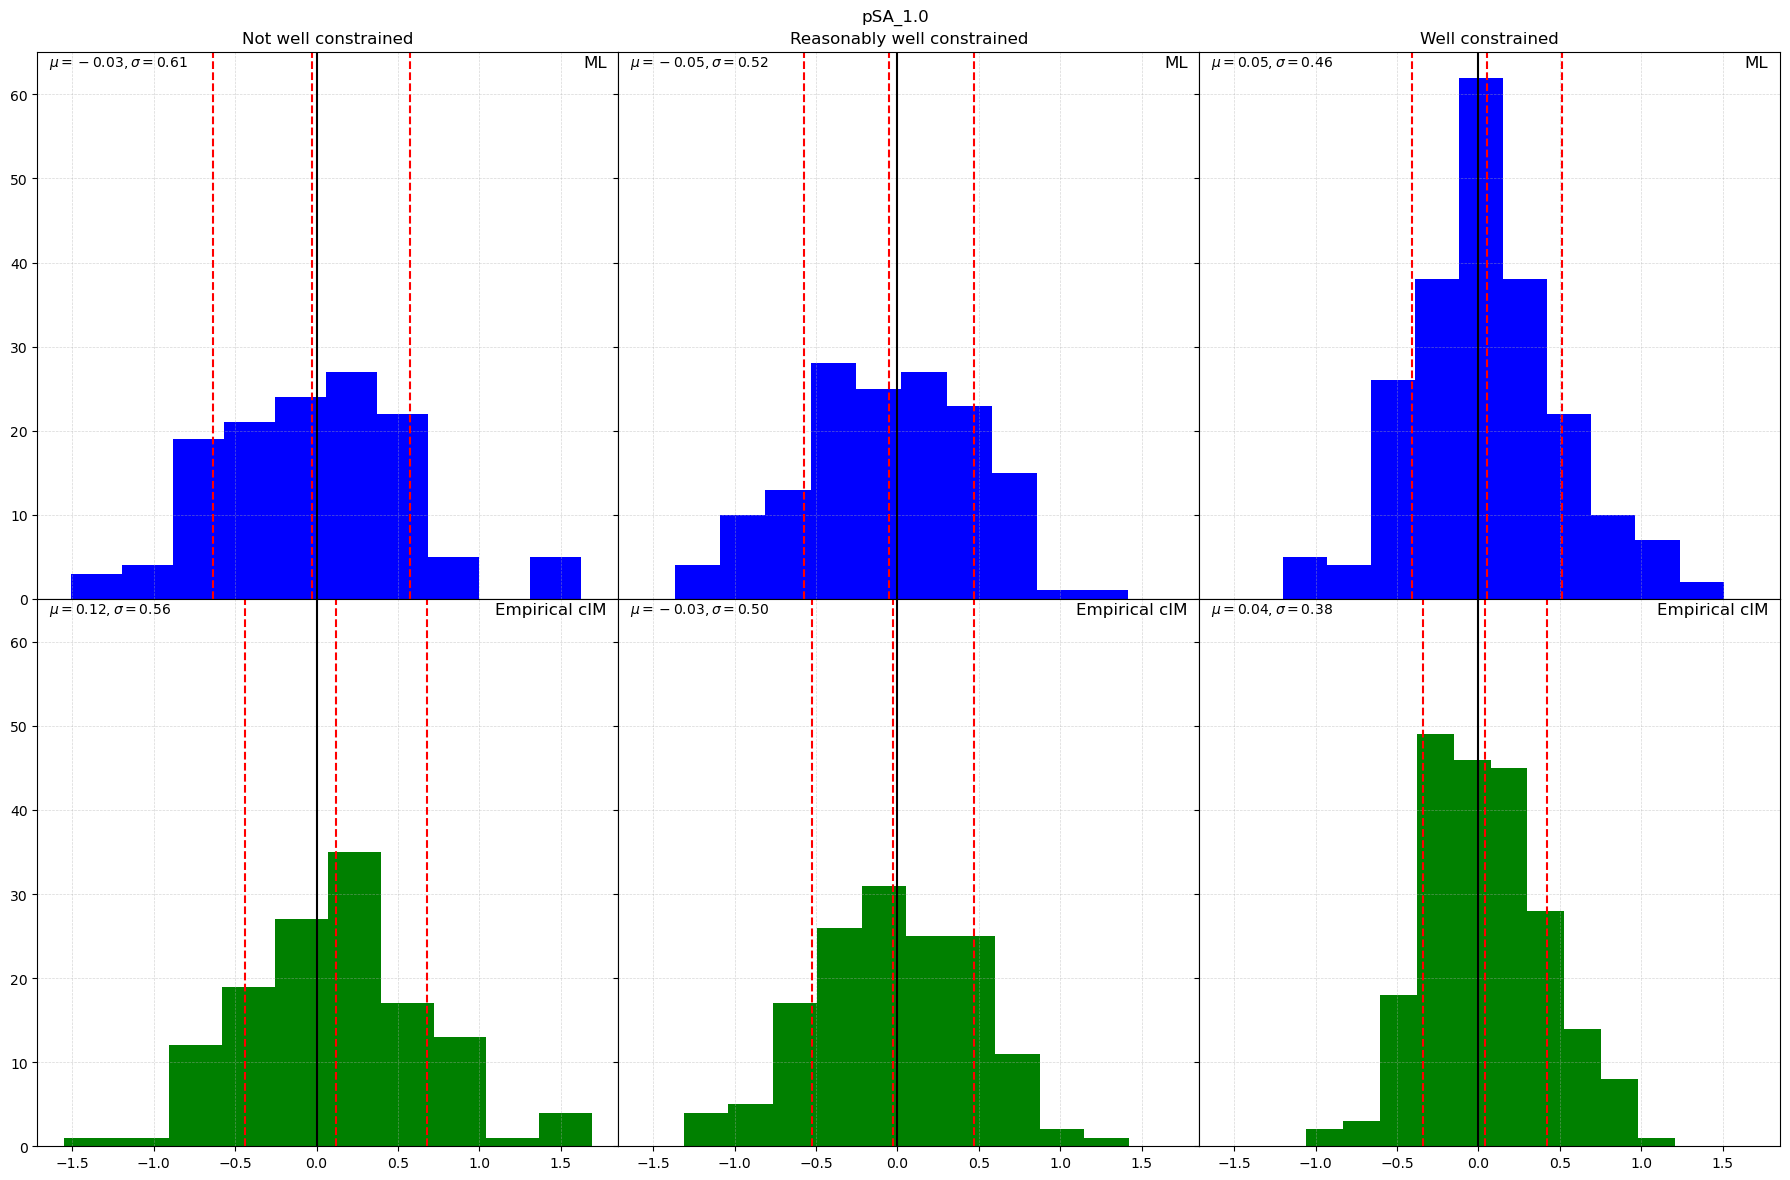

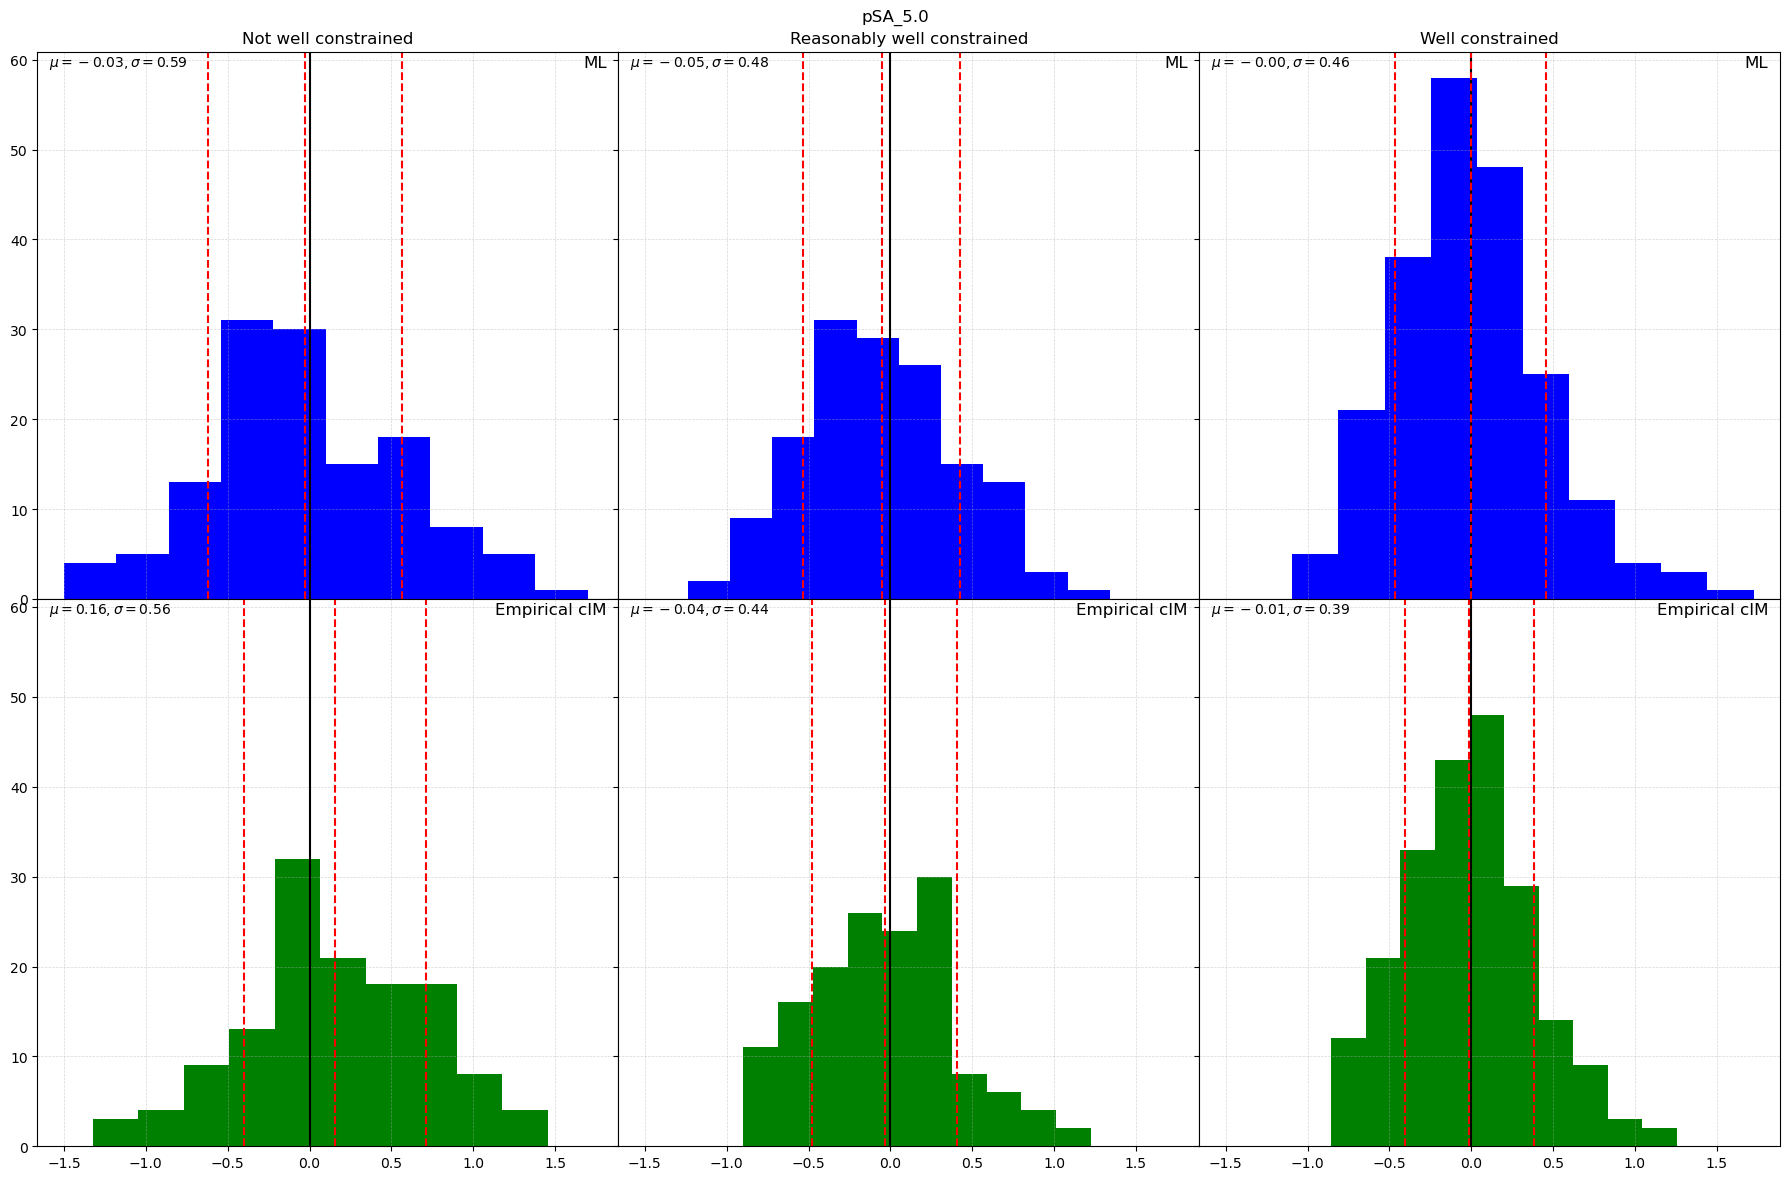

In [145]:
ims = ["pSA_0.01", "pSA_0.05", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_5.0"]

for cur_im in ims:	
	## Individual IM histogram
	def process_ax(ax, df, title=None, result_type=None, c=None, bins=20):
		cur_mean, cur_std = df.mean(), df.std()
		ax.hist(df, bins=bins, color=c)
		ax.axvline(0, c="k", linestyle="-")
		ax.axvline(cur_mean, c="r", linestyle="--")
		ax.axvline(cur_mean + cur_std, c="r", linestyle="--")
		ax.axvline(cur_mean - cur_std, c="r", linestyle="--")
		ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
		
		if title is not None:
			ax.set_title(title)
		
		ax.text(0.02, 0.98, f"$\mu = {cur_mean:.2f}, \sigma = {cur_std:.2f}$", horizontalalignment="left", verticalalignment="center", transform=ax.transAxes)
		
		if result_type is not None:
			ax.text(0.98, 0.98, f"{result_type}", horizontalalignment="right", verticalalignment="center", transform=ax.transAxes, fontsize=12)
			
		
	fig, axs = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)
	
	bins = 10
	
	# ML
	process_ax(axs[0, 0], ml_obs_residuals.loc[nwc, cur_im], "Not well constrained", result_type="ML", bins=bins, c="b")
	process_ax(axs[0, 1], ml_obs_residuals.loc[rwc, cur_im], "Reasonably well constrained", result_type="ML", bins=bins, c="b")
	process_ax(axs[0, 2], ml_obs_residuals.loc[wc, cur_im], "Well constrained", result_type="ML", bins=bins, c="b")
	
	process_ax(axs[1, 0], emp_cIM_obs_residuals.loc[nwc, cur_im], result_type="Empirical cIM", bins=bins, c="g")
	process_ax(axs[1, 1], emp_cIM_obs_residuals.loc[rwc, cur_im], result_type="Empirical cIM", bins=bins, c="g")
	process_ax(axs[1, 2], emp_cIM_obs_residuals.loc[wc, cur_im], result_type="Empirical cIM", bins=bins, c="g")
	
	fig.suptitle(f"{cur_im}")
	
	fig.tight_layout()
	fig.subplots_adjust(wspace=0, hspace=0)


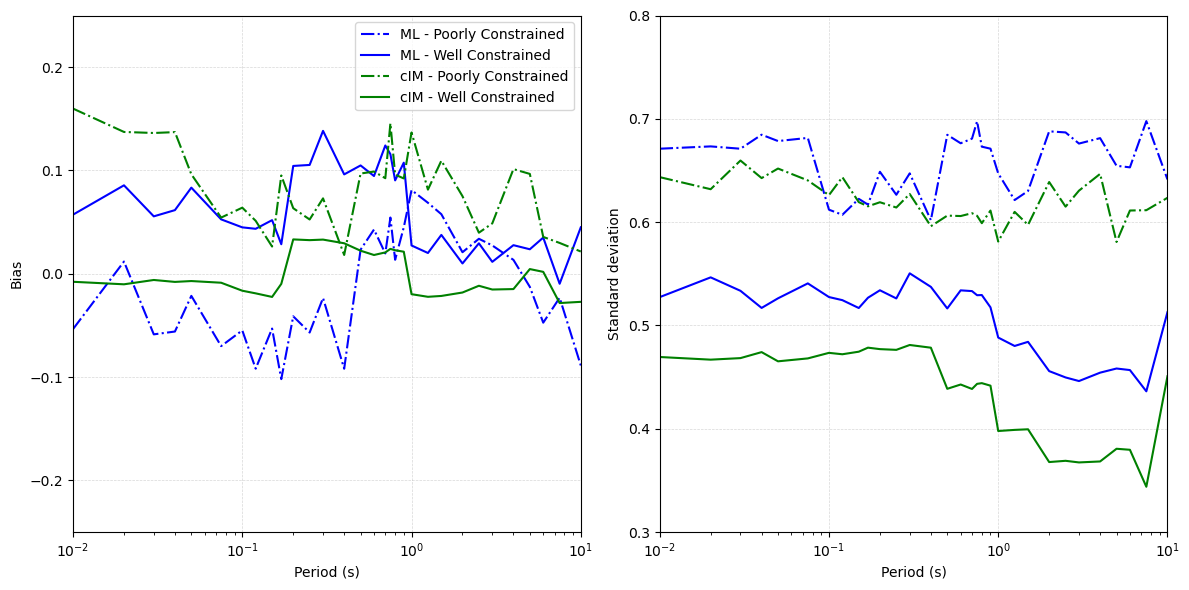

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ml_nwc_mean, ml_nwc_std = ml_obs_residuals.loc[nwc, ims].mean(), ml_obs_residuals.loc[nwc, ims].std()
ml_rwc_mean, ml_rwc_std = ml_obs_residuals.loc[rwc, ims].mean(), ml_obs_residuals.loc[rwc, ims].std()
ml_wc_mean, ml_wc_std = ml_obs_residuals.loc[wc, ims].mean(), ml_obs_residuals.loc[wc, ims].std()

emp_cIM_nwc_mean, emp_cIM_nwc_std = emp_cIM_obs_residuals.loc[nwc, ims].mean(), emp_cIM_obs_residuals.loc[nwc, ims].std()
emp_cIM_rwc_mean, emp_cIM_rwc_std = emp_cIM_obs_residuals.loc[rwc, ims].mean(), emp_cIM_obs_residuals.loc[rwc, ims].std()
emp_cIM_wc_mean, emp_cIM_wc_std = emp_cIM_obs_residuals.loc[wc, ims].mean(), emp_cIM_obs_residuals.loc[wc, ims].std()


## Mean

# ML
# ax1.semilogx(sr.constants.PERIODS, ml_nwc_mean, c="b", label="ML - NWC", linestyle="dashdot")
# ax1.semilogx(sr.constants.PERIODS, ml_rwc_mean, c="b", label="ML - RWC", linestyle="--")
# ax1.semilogx(sr.constants.PERIODS, ml_wc_mean, c="b", linestyle="-", label="ML - WC")

ax1.semilogx(sr.constants.PERIODS, ml_nwc_mean, c="b", label="ML - Poorly Constrained", linestyle="dashdot")
ax1.semilogx(sr.constants.PERIODS, ml_wc_mean, c="b", linestyle="-", label="ML - Well Constrained")

# emp cIM
# ax1.semilogx(sr.constants.PERIODS, emp_cIM_nwc_mean, c="g", label="cIM - NWC", linestyle="dashdot")
# ax1.semilogx(sr.constants.PERIODS, emp_cIM_rwc_mean, c="g", linestyle="--", label="cIM - RWC")
# ax1.semilogx(sr.constants.PERIODS, emp_cIM_wc_mean, c="g", linestyle="-", label="cIM - WC")

ax1.semilogx(sr.constants.PERIODS, emp_cIM_nwc_mean, c="g", label="cIM - Poorly Constrained", linestyle="dashdot")
ax1.semilogx(sr.constants.PERIODS, emp_cIM_wc_mean, c="g", linestyle="-", label="cIM - Well Constrained")

ax1.set_ylabel("Bias")
ax1.set_xlabel("Period (s)")
ax1.set_ylim(-0.25, 0.25)
ax1.set_xlim(0.01, 10)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.legend()

## Std
ax2.semilogx(sr.constants.PERIODS, ml_nwc_std, c="b", linestyle="dashdot")
# ax2.semilogx(sr.constants.PERIODS, ml_rwc_std, c="b", linestyle="--")
ax2.semilogx(sr.constants.PERIODS, ml_wc_std, c="b")

ax2.semilogx(sr.constants.PERIODS, emp_cIM_nwc_std, c="g", linestyle="dashdot")
# ax2.semilogx(sr.constants.PERIODS, emp_cIM_rwc_std, c="g", linestyle="--")
ax2.semilogx(sr.constants.PERIODS, emp_cIM_wc_std, c="g")

ax2.set_ylabel("Standard deviation")
ax2.set_xlabel("Period (s)")
ax2.set_ylim(0.3, 0.8)
ax2.set_xlim(0.01, 10)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.tight_layout()


## Site-condition differences
Look at how differences in the site conditions between the site of interest and observation sites affect residuals?
Unsure how to do this best